# Agrupamiento de clientes (Mall Customers)

Objetivo: segmentar clientes segun su edad, ingreso y comportamiento de gasto.

Pipeline:
1. Carga y exploracion inicial.
2. Analisis exploratorio (EDA).
3. Preprocesamiento.
4. K-Means.
5. DBSCAN.
6. Clustering jerarquico.
7. PCA y comparacion.
8. Conclusiones.

## 1. Importacion de librerias

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
 )
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
          '#1abc9c','#e67e22','#34495e','#e91e8c','#00bcd4']

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Carga de datos

Se usa el archivo local datasets/Ejercicio 4/Mall_Customers.csv.

In [5]:
data_path = "..\\datasets\\Ejercicio 4\\Mall_Customers.csv"
df = pd.read_csv(data_path)

print(f'Ruta      : {data_path}')
print(f'Filas     : {df.shape[0]}')
print(f'Columnas  : {df.shape[1]}')
print(f'Nombres   : {list(df.columns)}')

Ruta      : ..\datasets\Ejercicio 4\Mall_Customers.csv
Filas     : 200
Columnas  : 5
Nombres   : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## 3. Exploracion inicial del dataset

In [6]:
print('── Primeras 10 filas ──')
display(df.head(10))

── Primeras 10 filas ──


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
print('── Información general ──')
df.info()

── Información general ──
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
print('── Estadísticas descriptivas ──')
display(df.describe().round(2))

print('\n── Valores nulos por columna ──')
print(df.isnull().sum())

print('\n── Distribución por género ──')
print(df['Gender'].value_counts())

── Estadísticas descriptivas ──


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00



── Valores nulos por columna ──
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

── Distribución por género ──
Gender
Female    112
Male       88
Name: count, dtype: int64


## 4. Analisis exploratorio de datos (EDA)

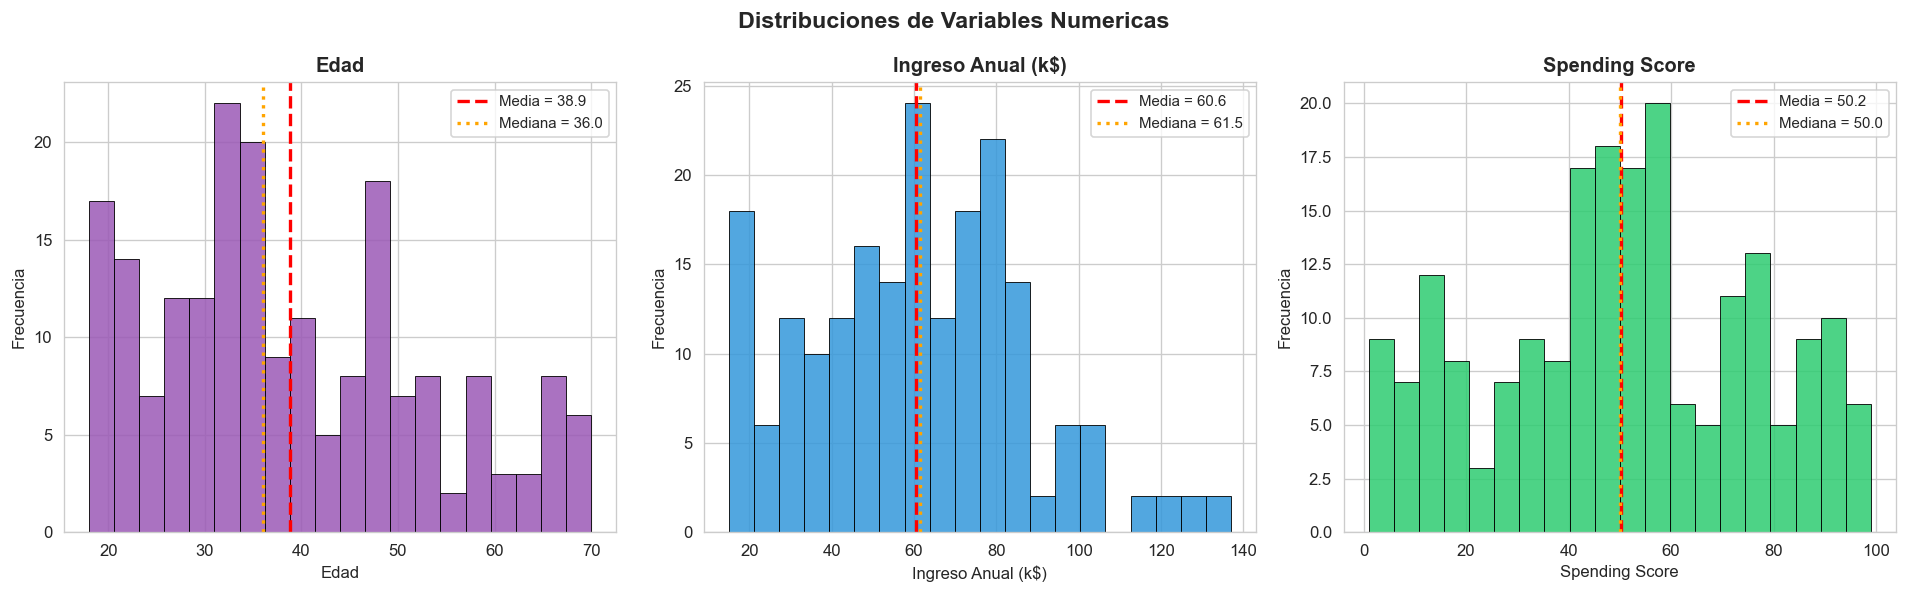

In [9]:
# ── 4.1 Distribuciones univariadas ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuciones de Variables Numericas', fontsize=14, fontweight='bold')

vars_info = [
    ('Age',                    '#9b59b6', 'Edad'),
    ('Annual Income (k$)',     '#3498db', 'Ingreso Anual (k$)'),
    ('Spending Score (1-100)', '#2ecc71', 'Spending Score'),
]

for ax, (var, color, titulo) in zip(axes, vars_info):
    ax.hist(df[var], bins=20, color=color, edgecolor='black', alpha=0.85, linewidth=0.6)
    ax.axvline(df[var].mean(),   color='red',    linestyle='--', lw=2,
               label=f'Media = {df[var].mean():.1f}')
    ax.axvline(df[var].median(), color='orange', linestyle=':',  lw=2,
               label=f'Mediana = {df[var].median():.1f}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

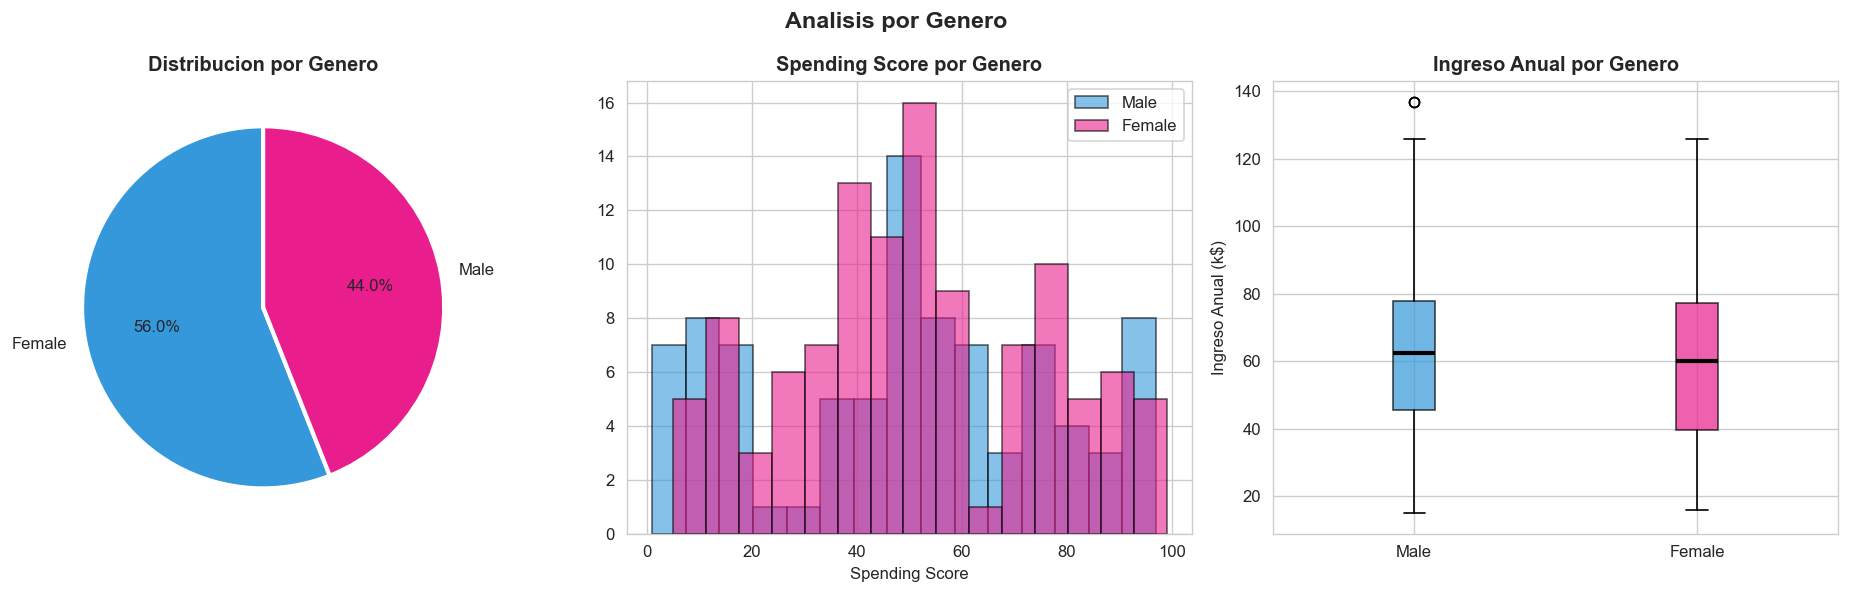

In [10]:
# ── 4.2 Analisis por genero ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analisis por Genero', fontsize=14, fontweight='bold')

# Pie chart
counts = df['Gender'].value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#3498db','#e91e8c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2.5))
axes[0].set_title('Distribucion por Genero', fontweight='bold')

# Spending Score por genero
for genero, color in zip(['Male','Female'], ['#3498db','#e91e8c']):
    data = df[df['Gender'] == genero]['Spending Score (1-100)']
    axes[1].hist(data, bins=15, alpha=0.6, color=color, label=genero, edgecolor='black')
axes[1].set_title('Spending Score por Genero', fontweight='bold')
axes[1].set_xlabel('Spending Score')
axes[1].legend()

# Ingreso por genero (boxplot)
bp = axes[2].boxplot(
    [df[df['Gender']=='Male']['Annual Income (k$)'],
     df[df['Gender']=='Female']['Annual Income (k$)']],
    labels=['Male','Female'], patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5)
)
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e91e8c'); bp['boxes'][1].set_alpha(0.7)
axes[2].set_title('Ingreso Anual por Genero', fontweight='bold')
axes[2].set_ylabel('Ingreso Anual (k$)')

plt.tight_layout()
plt.show()

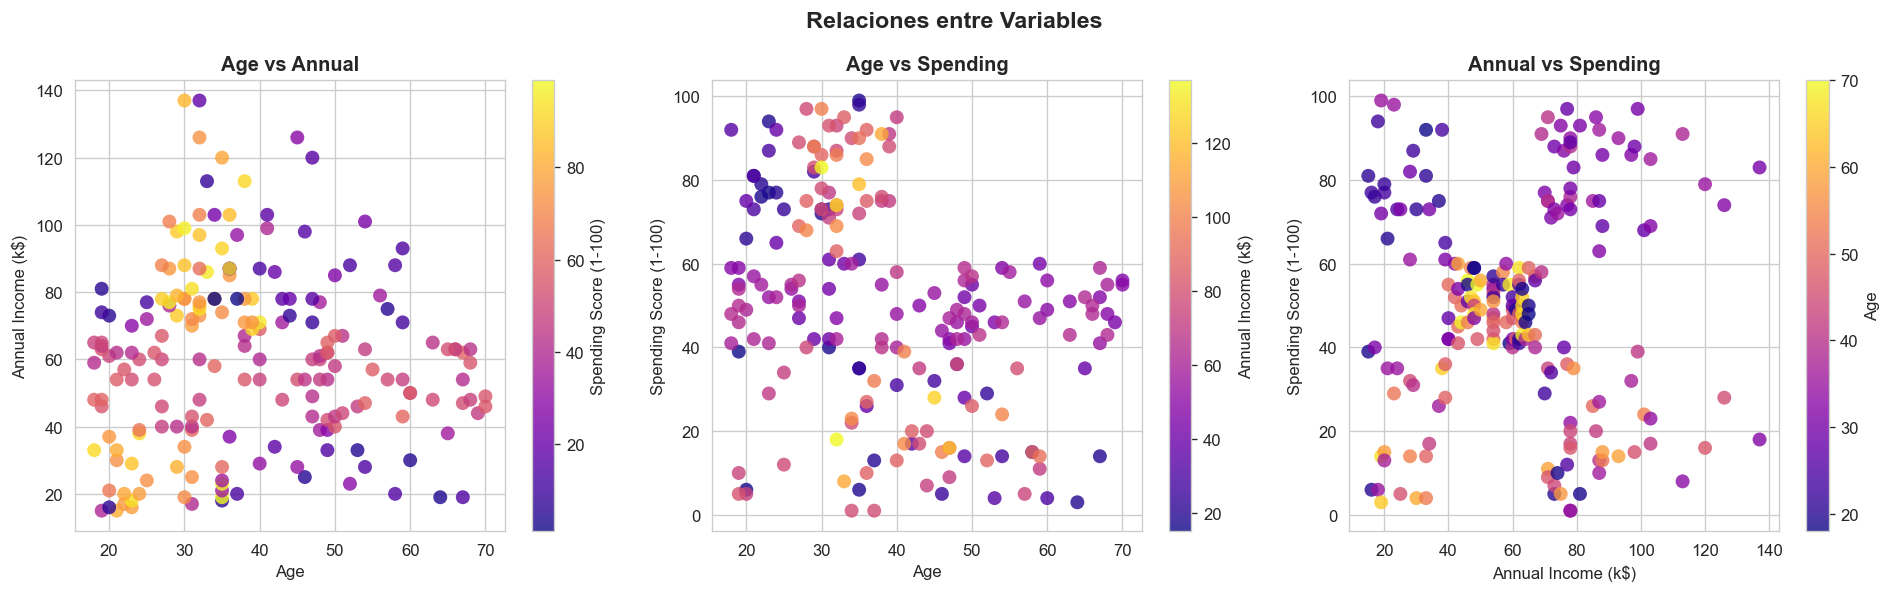

In [11]:
# ── 4.3 Scatter plots entre variables ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Relaciones entre Variables', fontsize=14, fontweight='bold')

pares = [
    ('Age',               'Annual Income (k$)',      'Spending Score (1-100)'),
    ('Age',               'Spending Score (1-100)',   'Annual Income (k$)'),
    ('Annual Income (k$)','Spending Score (1-100)',   'Age'),
]
for ax, (x, y, c) in zip(axes, pares):
    sc = ax.scatter(df[x], df[y], c=df[c], cmap='plasma',
                    s=70, alpha=0.8, edgecolors='none')
    plt.colorbar(sc, ax=ax, label=c)
    ax.set_xlabel(x); ax.set_ylabel(y)
    titulo = f'{x.split(" ")[0]} vs {y.split(" ")[0]}'
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

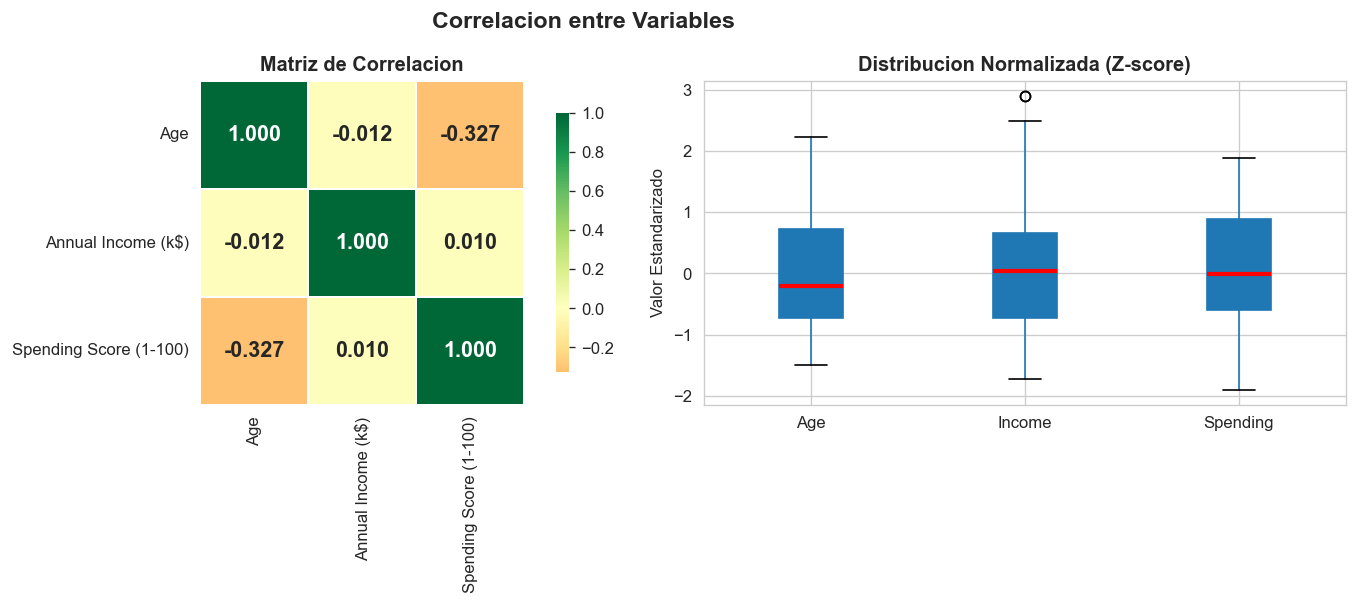

In [12]:
# ── 4.4 Correlacion ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Correlacion entre Variables', fontsize=14, fontweight='bold')

cols_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[cols_num].corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=1, square=True,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz de Correlacion', fontweight='bold')

# Boxplots normalizados
df_z = (df[cols_num] - df[cols_num].mean()) / df[cols_num].std()
df_z.boxplot(ax=axes[1], patch_artist=True,
             medianprops=dict(color='red', linewidth=2.5))
axes[1].set_title('Distribucion Normalizada (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor Estandarizado')
axes[1].set_xticklabels(['Age','Income','Spending'], rotation=0)

plt.tight_layout()
plt.show()

## 5. Preprocesamiento

In [13]:
# Seleccion de variables
USE_GENDER = False
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

if USE_GENDER:
    le = LabelEncoder()
    df['Gender_enc'] = le.fit_transform(df['Gender'])  # Female=0, Male=1
    features.append('Gender_enc')

X = df[features].values

# Estandarizacion
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Preprocesamiento completado')
print(f'Clientes        : {X.shape[0]}')
print(f'Features usadas : {features}')
print(f'Media escalada  : {X_scaled.mean(axis=0).round(5)}')
print(f'Std escalada    : {X_scaled.std(axis=0).round(5)}')

Preprocesamiento completado
Clientes        : 200
Features usadas : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Media escalada  : [-0. -0. -0.]
Std escalada    : [1. 1. 1.]


## 6. Modelo 1: K-Means

Justificacion: K-Means es eficiente y suele encontrar grupos compactos cuando las variables estan estandarizadas.

In [31]:
# ── Búsqueda del K óptimo ────────────────────────────────────
print(' Calculando métricas para k = 2 a 10...')

k_range     = range(2, 11)
inertias    = []
silhouettes = []
dbs         = []
chs         = []

for k in k_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    dbs.append(davies_bouldin_score(X_scaled, lbl))
    chs.append(calinski_harabasz_score(X_scaled, lbl))
    print(f'   k={k}  Silhouette={silhouettes[-1]:.4f}  DB={dbs[-1]:.4f}  CH={chs[-1]:.1f}')

K_OPT = list(k_range)[np.argmax(silhouettes)]
print(f'\nK óptimo: k = {K_OPT}  (Silhouette = {max(silhouettes):.4f})')

 Calculando métricas para k = 2 a 10...
   k=2  Silhouette=0.3355  DB=1.2607  CH=107.1
   k=3  Silhouette=0.3578  DB=1.0503  CH=101.7
   k=4  Silhouette=0.4040  DB=0.9308  CH=125.7
   k=5  Silhouette=0.4166  DB=0.8746  CH=125.1
   k=6  Silhouette=0.4274  DB=0.8277  CH=135.1
   k=7  Silhouette=0.4172  DB=0.7935  CH=132.8
   k=8  Silhouette=0.4087  DB=0.8893  CH=131.1
   k=9  Silhouette=0.4201  DB=0.8541  CH=131.2
   k=10  Silhouette=0.3973  DB=0.9056  CH=133.4

K óptimo: k = 6  (Silhouette = 0.4274)


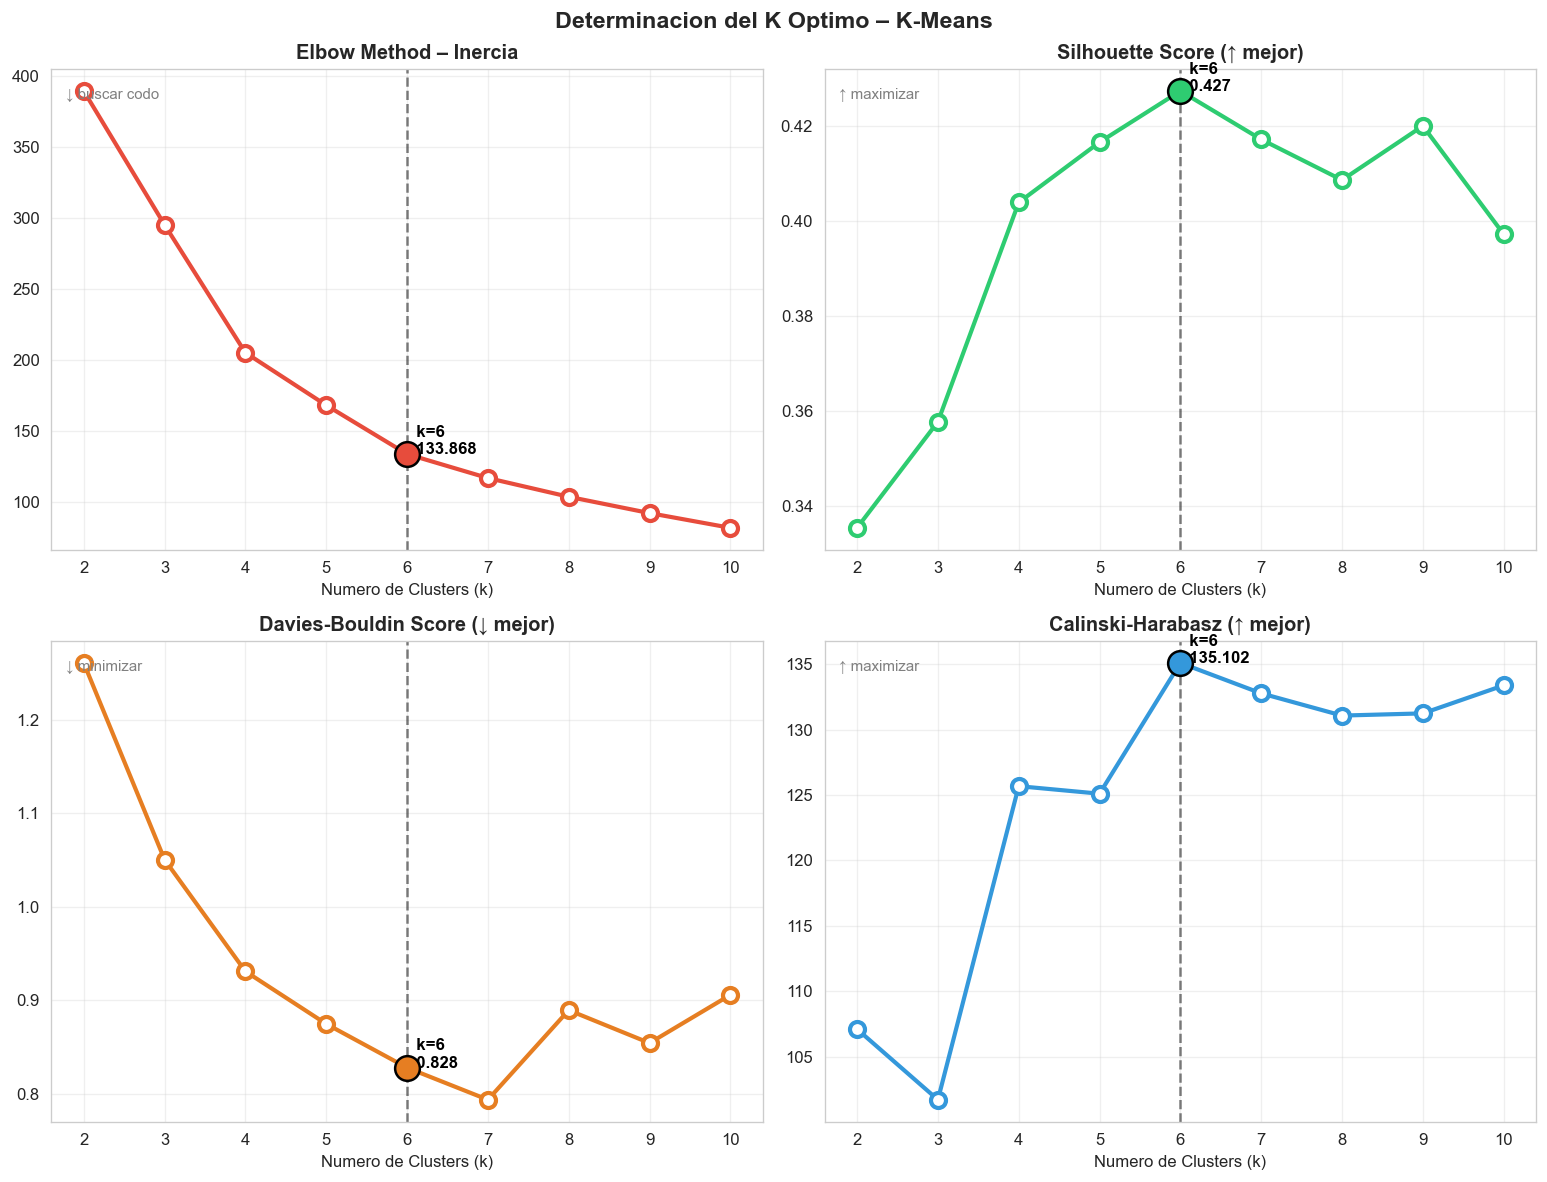

In [15]:
# ── Visualizacion del K optimo ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Determinacion del K Optimo – K-Means', fontsize=14, fontweight='bold')

metricas_k = [
    ('Elbow Method – Inercia',        inertias,    '#e74c3c', '↓ buscar codo'),
    ('Silhouette Score (↑ mejor)',     silhouettes, '#2ecc71', '↑ maximizar'),
    ('Davies-Bouldin Score (↓ mejor)', dbs,         '#e67e22', '↓ minimizar'),
    ('Calinski-Harabasz (↑ mejor)',    chs,         '#3498db', '↑ maximizar'),
]

for ax, (titulo, datos, color, nota) in zip(axes.flat, metricas_k):
    ax.plot(list(k_range), datos, 'o-', color=color, lw=2.5, ms=9,
            markerfacecolor='white', markeredgewidth=2.5)
    idx_k = list(k_range).index(K_OPT)
    ax.axvline(K_OPT, color='black', linestyle='--', alpha=0.5, lw=1.5)
    ax.scatter([K_OPT], [datos[idx_k]], s=220, color=color,
               zorder=5, edgecolors='black', linewidths=1.5)
    ax.annotate(f'  k={K_OPT}\n  {datos[idx_k]:.3f}',
                xy=(K_OPT, datos[idx_k]), fontsize=10, fontweight='bold',
                color='black')
    ax.set_xlabel('Numero de Clusters (k)', fontsize=10)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(list(k_range))
    ax.grid(alpha=0.3)
    ax.text(0.02, 0.96, nota, transform=ax.transAxes,
            fontsize=9, color='gray', va='top')

plt.tight_layout()
plt.show()

In [16]:
# ── Entrenar K-Means final ───────────────────────────────────
kmeans = KMeans(n_clusters=K_OPT, init='k-means++', n_init=50, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df['Cluster_KMeans'])
db_km  = davies_bouldin_score(X_scaled, df['Cluster_KMeans'])
ch_km  = calinski_harabasz_score(X_scaled, df['Cluster_KMeans'])

print(f'K-Means entrenado (k={K_OPT})')
print(f'   Silhouette Score    : {sil_km:.4f}')
print(f'   Davies-Bouldin      : {db_km:.4f}')
print(f'   Calinski-Harabasz   : {ch_km:.1f}')

print('\nPerfil de clusters:')
perfil = df.groupby('Cluster_KMeans')[features].mean().round(1)
perfil['Tamaño'] = df['Cluster_KMeans'].value_counts().sort_index()
display(perfil)

K-Means entrenado (k=6)
   Silhouette Score    : 0.4274
   Davies-Bouldin      : 0.8277
   Calinski-Harabasz   : 135.1

Perfil de clusters:


,Age,Annual Income (k$),Spending Score (1-100),Tamaño
Cluster_KMeans,,,,
0,41.9,88.9,17.0,33
1,56.3,54.3,49.1,45
2,25.2,25.8,76.9,24
3,32.7,86.5,82.1,39
4,26.7,57.6,47.8,38
5,45.5,26.3,19.4,21


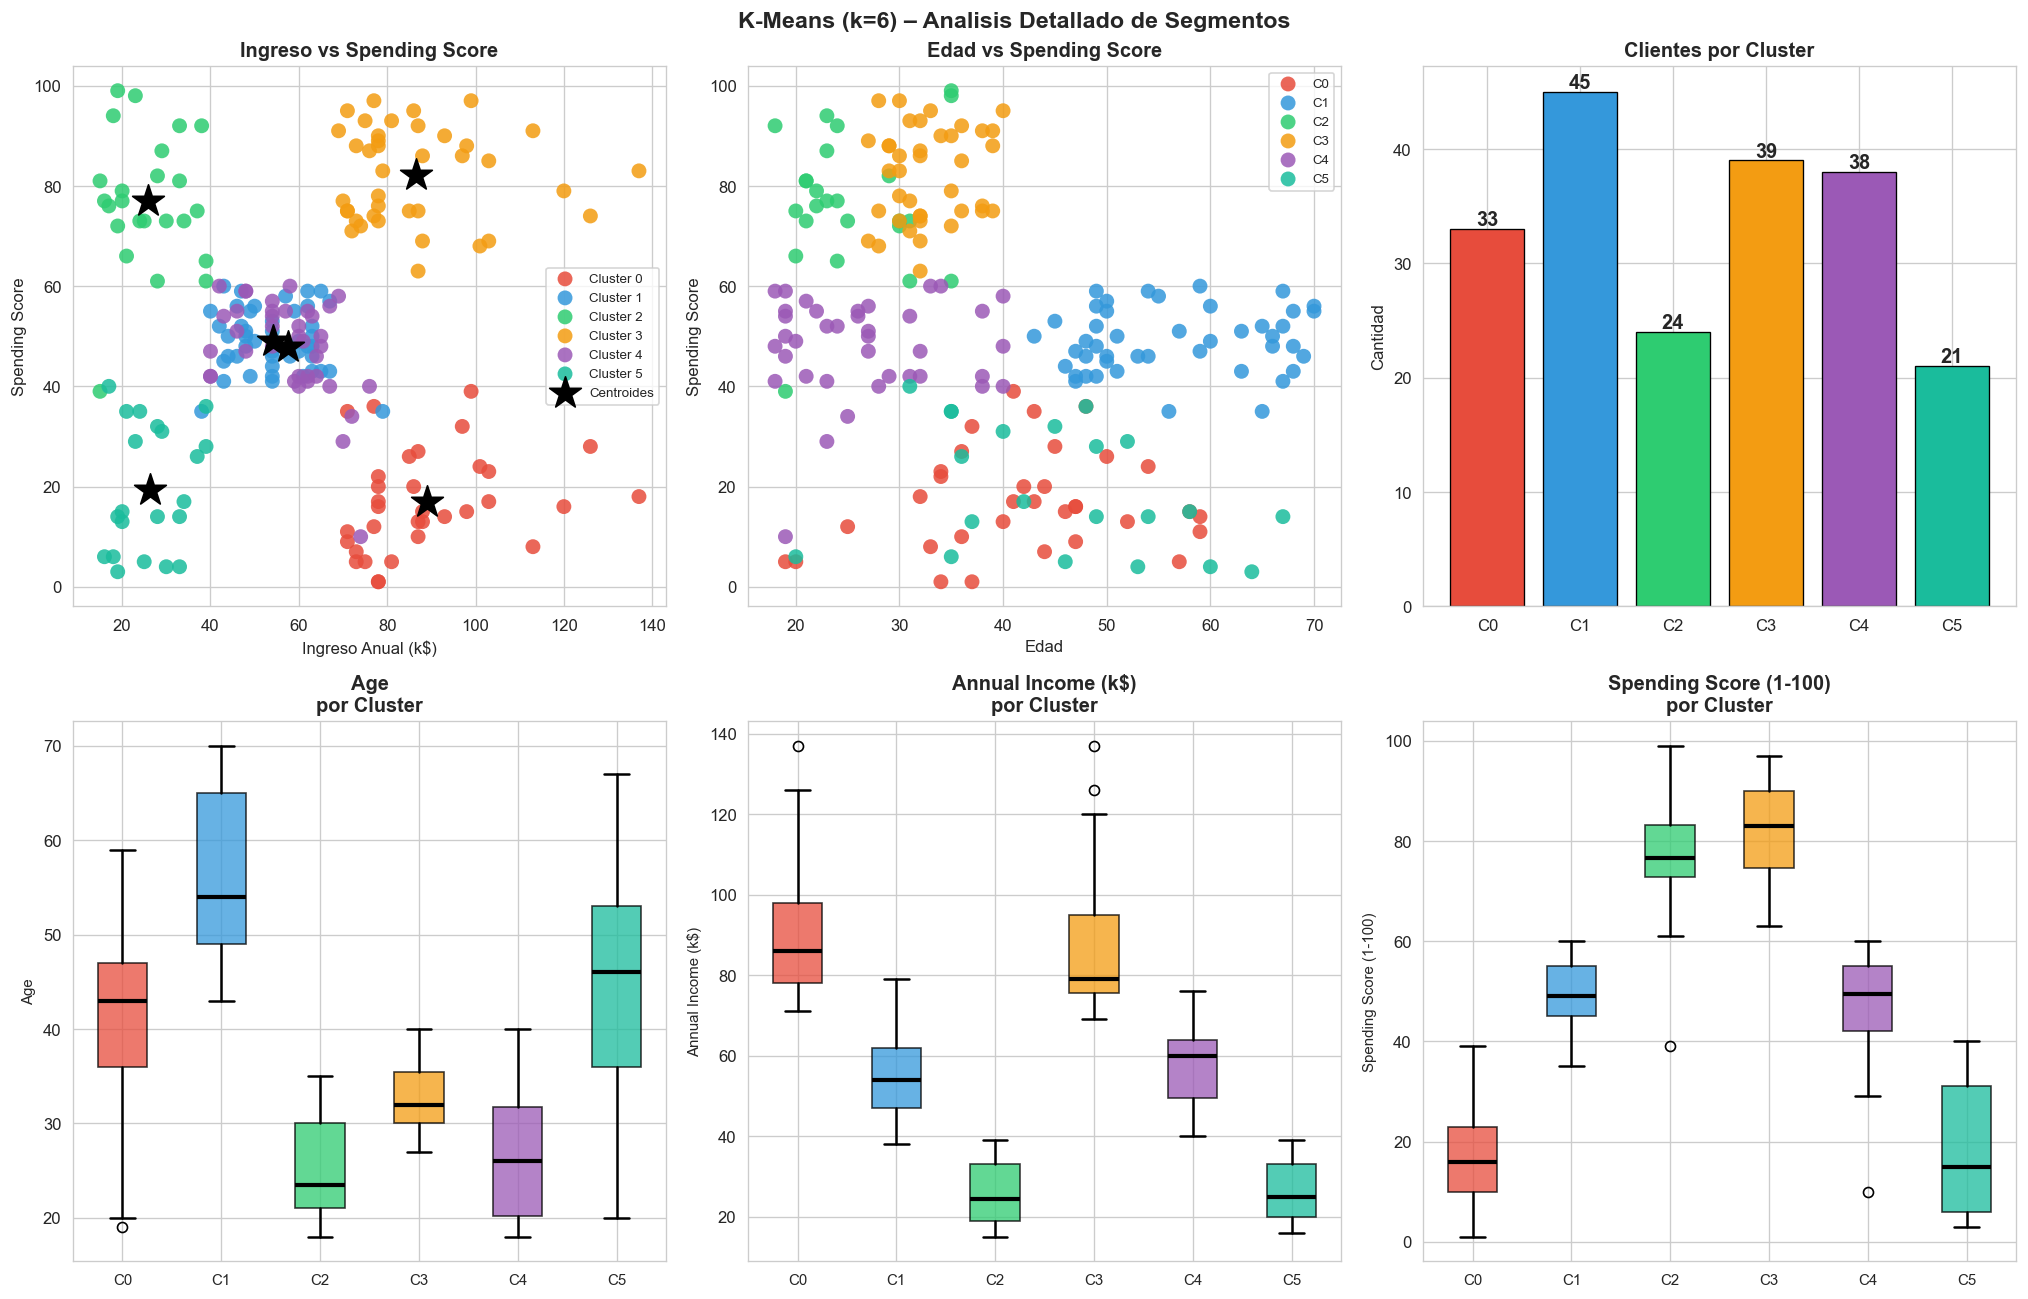

In [17]:
# ── Visualizacion detallada K-Means ─────────────────────────
c_colors  = [COLORS[i] for i in range(K_OPT)]
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle(f'K-Means (k={K_OPT}) – Analisis Detallado de Segmentos',
             fontsize=14, fontweight='bold')

# Ingreso vs Spending
ax = axes[0, 0]
for k in range(K_OPT):
    mask = df['Cluster_KMeans'] == k
    ax.scatter(df.loc[mask,'Annual Income (k$)'],
               df.loc[mask,'Spending Score (1-100)'],
               c=COLORS[k], s=80, alpha=0.85, label=f'Cluster {k}', edgecolors='none')
ax.scatter(centroids[:,1], centroids[:,2], c='black',
           marker='*', s=400, zorder=5, label='Centroides')
ax.set_xlabel('Ingreso Anual (k$)'); ax.set_ylabel('Spending Score')
ax.set_title('Ingreso vs Spending Score', fontweight='bold')
ax.legend(fontsize=8)

# Edad vs Spending
ax = axes[0, 1]
for k in range(K_OPT):
    mask = df['Cluster_KMeans'] == k
    ax.scatter(df.loc[mask,'Age'], df.loc[mask,'Spending Score (1-100)'],
               c=COLORS[k], s=80, alpha=0.85, label=f'C{k}', edgecolors='none')
ax.set_xlabel('Edad'); ax.set_ylabel('Spending Score')
ax.set_title('Edad vs Spending Score', fontweight='bold')
ax.legend(fontsize=8)

# Tamano de clusters
ax = axes[0, 2]
sizes = df['Cluster_KMeans'].value_counts().sort_index()
bars  = ax.bar([f'C{i}' for i in sizes.index], sizes.values,
               color=c_colors, edgecolor='black', lw=0.8)
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Clientes por Cluster', fontweight='bold')
ax.set_ylabel('Cantidad')

# Boxplots por variable
for feat, ax in zip(features, [axes[1,0], axes[1,1], axes[1,2]]):
    data_bp = [df[df['Cluster_KMeans']==k][feat].values for k in range(K_OPT)]
    bp = ax.boxplot(data_bp, patch_artist=True,
                    medianprops=dict(color='black', lw=2.5),
                    whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5))
    for patch, color in zip(bp['boxes'], c_colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels([f'C{k}' for k in range(K_OPT)], fontsize=9)
    ax.set_title(f'{feat}\npor Cluster', fontweight='bold')
    ax.set_ylabel(feat, fontsize=9)

plt.tight_layout()
plt.show()

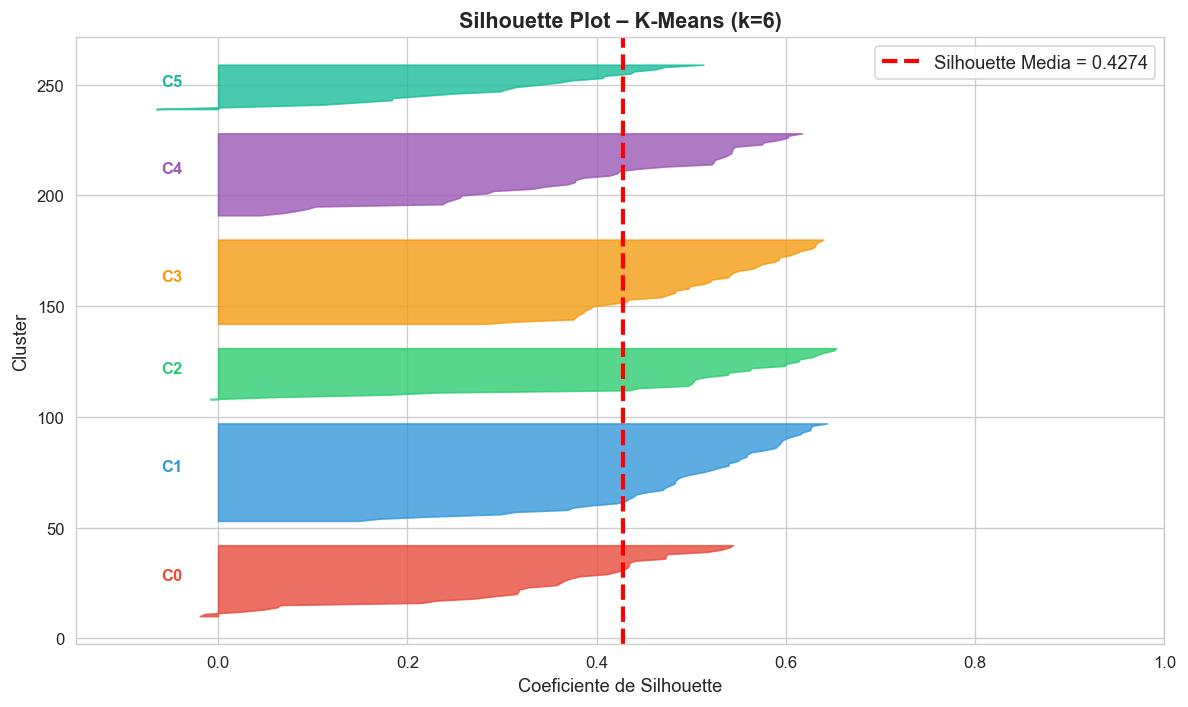

In [18]:
# ── Silhouette Plot ──────────────────────────────────────────
sil_vals = silhouette_samples(X_scaled, df['Cluster_KMeans'])

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for k in range(K_OPT):
    ith_sil = np.sort(sil_vals[df['Cluster_KMeans'] == k])
    size_k  = ith_sil.shape[0]
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=COLORS[k], edgecolor=COLORS[k], alpha=0.8)
    ax.text(-0.06, y_lower + 0.5*size_k, f'C{k}',
            fontsize=10, fontweight='bold', color=COLORS[k])
    y_lower = y_upper + 10

ax.axvline(sil_km, color='red', linestyle='--', lw=2.5,
           label=f'Silhouette Media = {sil_km:.4f}')
ax.set_xlabel('Coeficiente de Silhouette', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
ax.set_title(f'Silhouette Plot – K-Means (k={K_OPT})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xlim([-0.15, 1.0])

plt.tight_layout()
plt.show()

## 7. Modelo 2: DBSCAN

Justificacion: DBSCAN detecta clusters de forma arbitraria y marca como ruido los outliers.

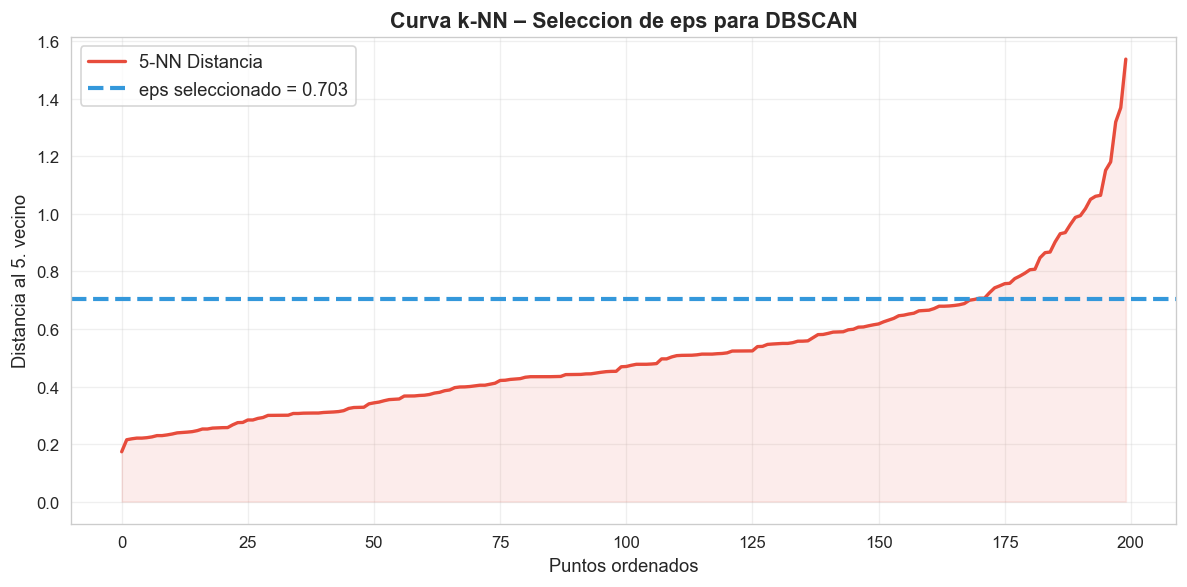

eps seleccionado: 0.7035


In [19]:
# ── Seleccion de eps con curva k-NN ─────────────────────────
nbrs         = NearestNeighbors(n_neighbors=5).fit(X_scaled)
dists, _     = nbrs.kneighbors(X_scaled)
dists_sorted = np.sort(dists[:, 4])
eps_auto     = float(np.percentile(dists_sorted, 85))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dists_sorted, color='#e74c3c', lw=2, label='5-NN Distancia')
ax.fill_between(range(len(dists_sorted)), dists_sorted, alpha=0.1, color='#e74c3c')
ax.axhline(eps_auto, color='#3498db', linestyle='--', lw=2.5,
           label=f'eps seleccionado = {eps_auto:.3f}')
ax.set_xlabel('Puntos ordenados', fontsize=11)
ax.set_ylabel('Distancia al 5. vecino', fontsize=11)
ax.set_title('Curva k-NN – Seleccion de eps para DBSCAN', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'eps seleccionado: {eps_auto:.4f}')

In [20]:
# ── Entrenar DBSCAN ──────────────────────────────────────────
dbscan               = DBSCAN(eps=eps_auto, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clust_db = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise    = (df['Cluster_DBSCAN'] == -1).sum()

print(f' DBSCAN entrenado')
print(f'eps            : {eps_auto:.4f}')
print(f'min_samples    : 5')
print(f'Clusters found : {n_clust_db}')
print(f'Puntos ruido   : {n_noise} ({n_noise/len(df)*100:.1f}%)')

mask_v = df['Cluster_DBSCAN'] != -1
if n_clust_db > 1 and mask_v.sum() > 1 and len(set(df.loc[mask_v,'Cluster_DBSCAN'])) > 1:
    sil_db = silhouette_score(X_scaled[mask_v], df.loc[mask_v,'Cluster_DBSCAN'])
    db_db  = davies_bouldin_score(X_scaled[mask_v], df.loc[mask_v,'Cluster_DBSCAN'])
    print(f'   Silhouette (sin ruido)      : {sil_db:.4f}')
    print(f'   Davies-Bouldin (sin ruido)  : {db_db:.4f}')
else:
    sil_db = 0.0; db_db = 0.0
    print('   ⚠ No suficientes clusters para calcular Silhouette Score')

 DBSCAN entrenado
eps            : 0.7035
min_samples    : 5
Clusters found : 1
Puntos ruido   : 14 (7.0%)
   ⚠ No suficientes clusters para calcular Silhouette Score


## 8. Modelo 3: Clustering jerarquico

Justificacion: el metodo Ward minimiza la varianza intra-cluster y permite visualizar la estructura con un dendrograma.

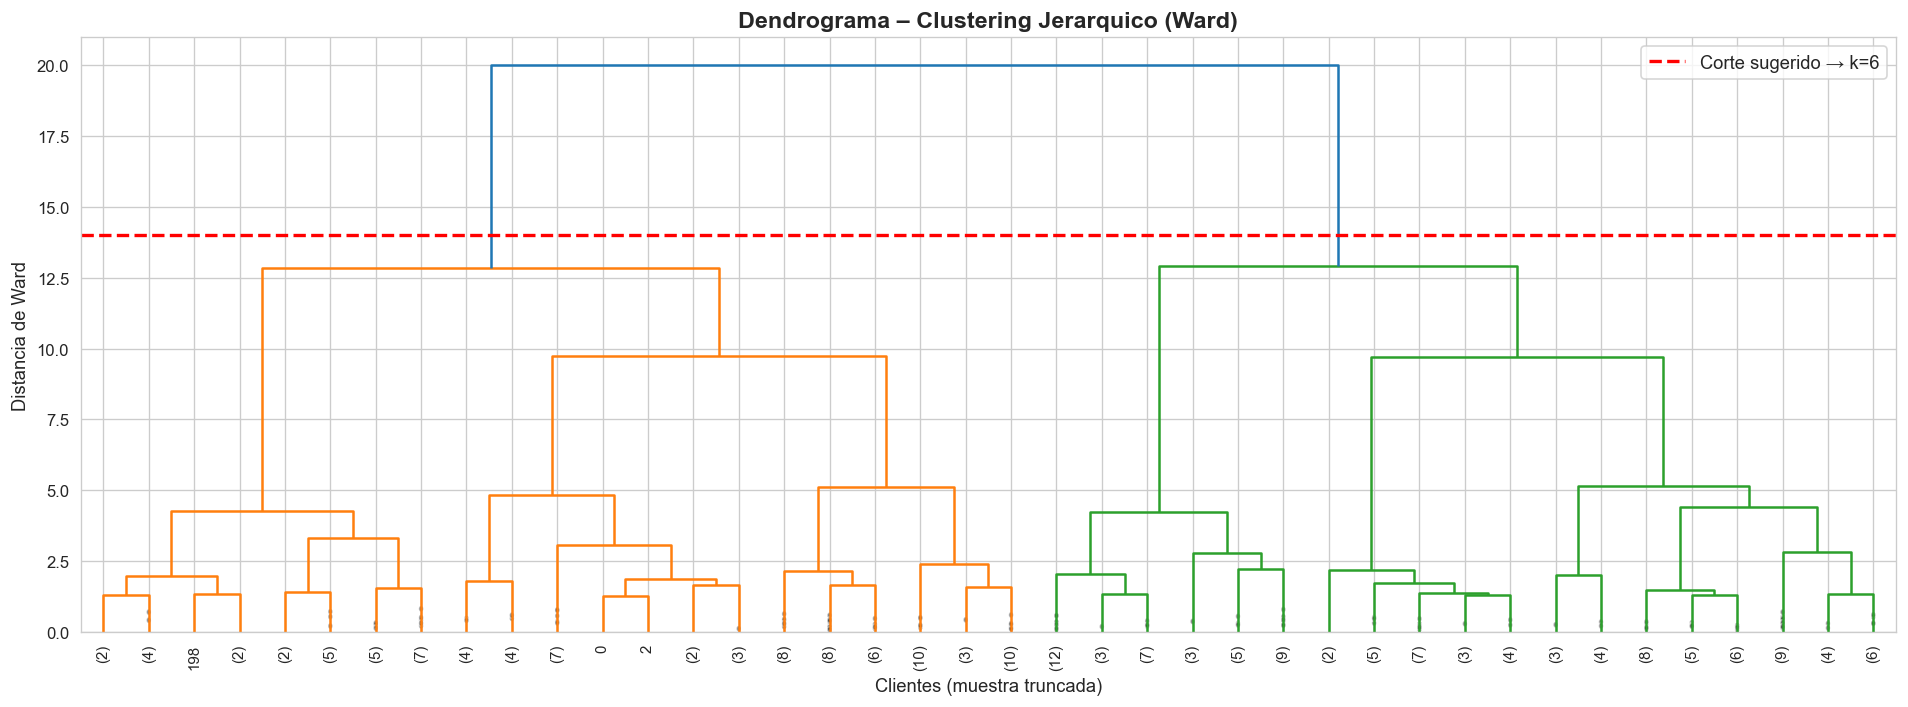

In [21]:
# ── Dendrograma ──────────────────────────────────────────────
lm = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    lm, ax=ax,
    truncate_mode='lastp', p=40,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(lm[:,2])
)
ax.axhline(y=0.7*max(lm[:,2]), color='red', linestyle='--',
           lw=2, label=f'Corte sugerido → k={K_OPT}')
ax.set_title('Dendrograma – Clustering Jerarquico (Ward)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Clientes (muestra truncada)', fontsize=11)
ax.set_ylabel('Distancia de Ward', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [22]:
# ── Entrenar Clustering Jerárquico ───────────────────────────
hier             = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
df['Cluster_Hier'] = hier.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, df['Cluster_Hier'])
db_hier  = davies_bouldin_score(X_scaled, df['Cluster_Hier'])
ch_hier  = calinski_harabasz_score(X_scaled, df['Cluster_Hier'])

print(f' Clustering Jerárquico (Ward, k={K_OPT})')
print(f'Silhouette Score    : {sil_hier:.4f}')
print(f'Davies-Bouldin      : {db_hier:.4f}')
print(f'Calinski-Harabasz   : {ch_hier:.1f}')

 Clustering Jerárquico (Ward, k=6)
Silhouette Score    : 0.4201
Davies-Bouldin      : 0.8521
Calinski-Harabasz   : 128.0


## 9. PCA y comparacion visual

In [23]:
# ── PCA ──────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_

print('📐 Resultados PCA:')
print(f'   PC1 varianza : {var[0]*100:.2f}%')
print(f'   PC2 varianza : {var[1]*100:.2f}%')
print(f'   Total        : {sum(var)*100:.2f}%')

print('\n   Loadings (contribución por variable):')
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=features
).round(4)
display(loadings)

📐 Resultados PCA:
   PC1 varianza : 44.27%
   PC2 varianza : 33.31%
   Total        : 77.57%

   Loadings (contribución por variable):


,PC1,PC2
Age,0.7064,0.0301
Annual Income (k$),-0.0480,0.9988
Spending Score (1-100),-0.7062,-0.0378


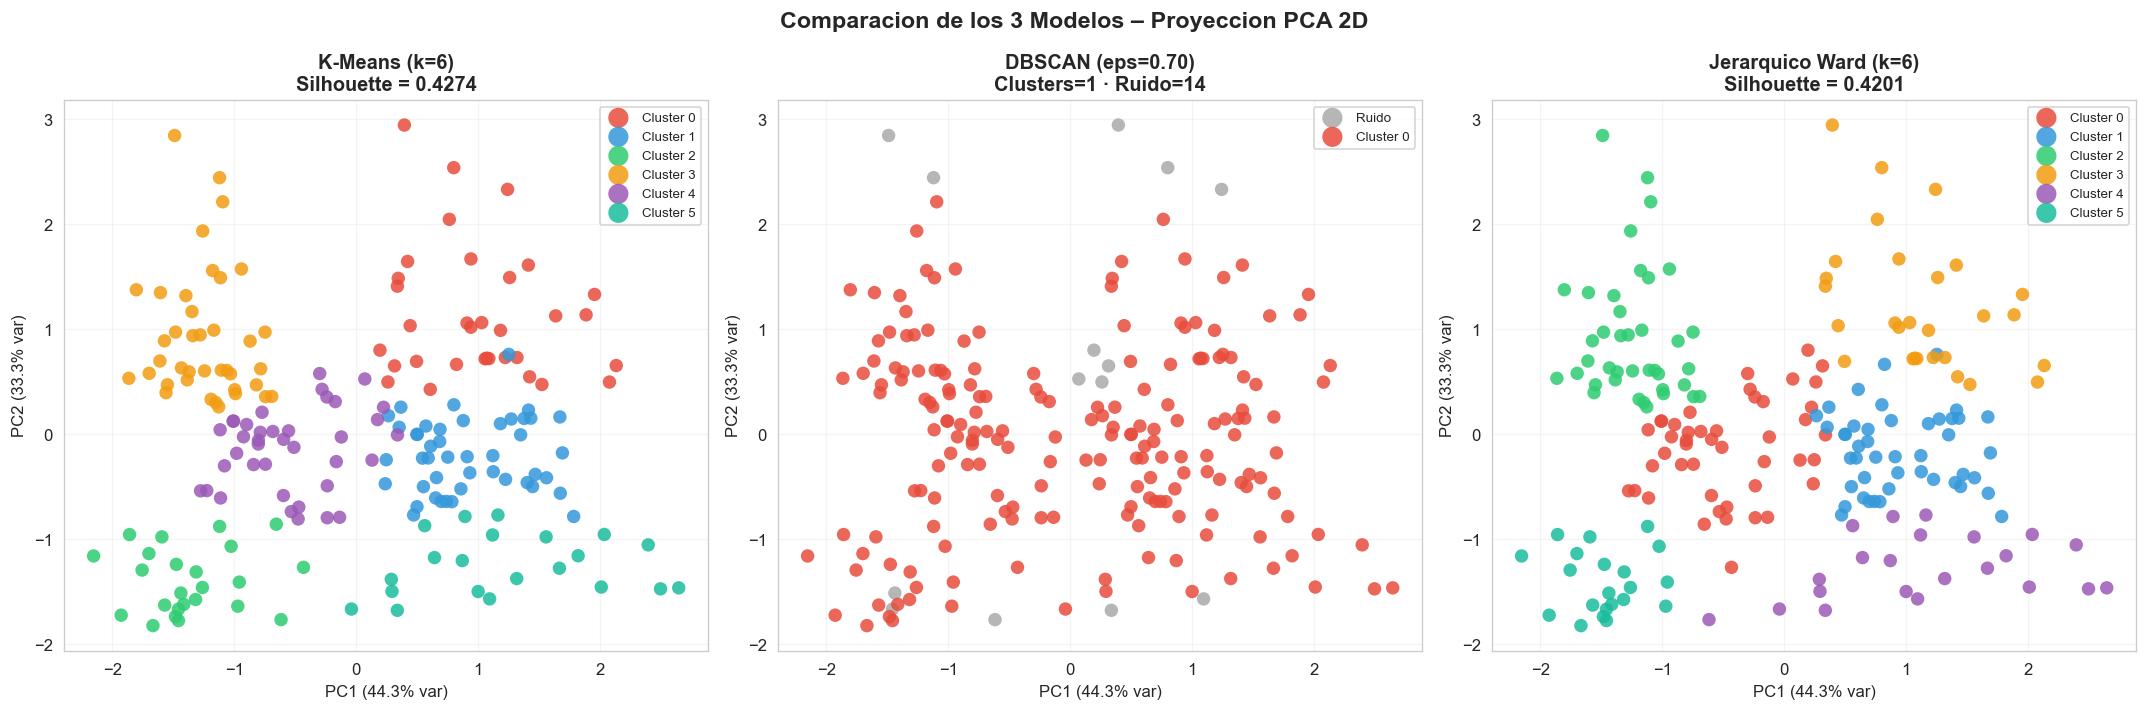

In [24]:
# ── Comparacion 3 modelos en PCA 2D ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparacion de los 3 Modelos – Proyeccion PCA 2D',
             fontsize=14, fontweight='bold')

configs = [
    ('Cluster_KMeans', f'K-Means (k={K_OPT})\nSilhouette = {sil_km:.4f}'),
    ('Cluster_DBSCAN', f'DBSCAN (eps={eps_auto:.2f})\nClusters={n_clust_db} · Ruido={n_noise}'),
    ('Cluster_Hier',   f'Jerarquico Ward (k={K_OPT})\nSilhouette = {sil_hier:.4f}'),
]

for ax, (col, titulo) in zip(axes, configs):
    for lbl in sorted(df[col].unique()):
        mask  = df[col] == lbl
        color = '#aaaaaa' if lbl == -1 else COLORS[lbl % len(COLORS)]
        label = 'Ruido' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color, label=label,
                   s=65, alpha=0.85, edgecolors='none')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)', fontsize=10)
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 10. Evaluacion y comparacion de modelos

In [25]:
# ── Tabla resumen ────────────────────────────────────────────
summary = pd.DataFrame({
    'Modelo':           ['K-Means', 'DBSCAN', 'Jerárquico (Ward)'],
    'N° Clusters':      [K_OPT, n_clust_db, K_OPT],
    'Silhouette ↑':     [round(sil_km,4), round(sil_db,4), round(sil_hier,4)],
    'Davies-Bouldin ↓': [round(db_km,4),  round(db_db,4),  round(db_hier,4)],
    'Calinski-H ↑':     [round(ch_km,1),  0.0,             round(ch_hier,1)],
    'Puntos Ruido':     [0, n_noise, 0],
})
print('RESUMEN COMPARATIVO:')
display(summary)

RESUMEN COMPARATIVO:


,Modelo,N° Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-H ↑,Puntos Ruido
0,K-Means,6,0.4274,0.8277,135.1,0
1,DBSCAN,1,0.0000,0.0000,0.0,14
2,Jerárquico (Ward),6,0.4201,0.8521,128.0,0


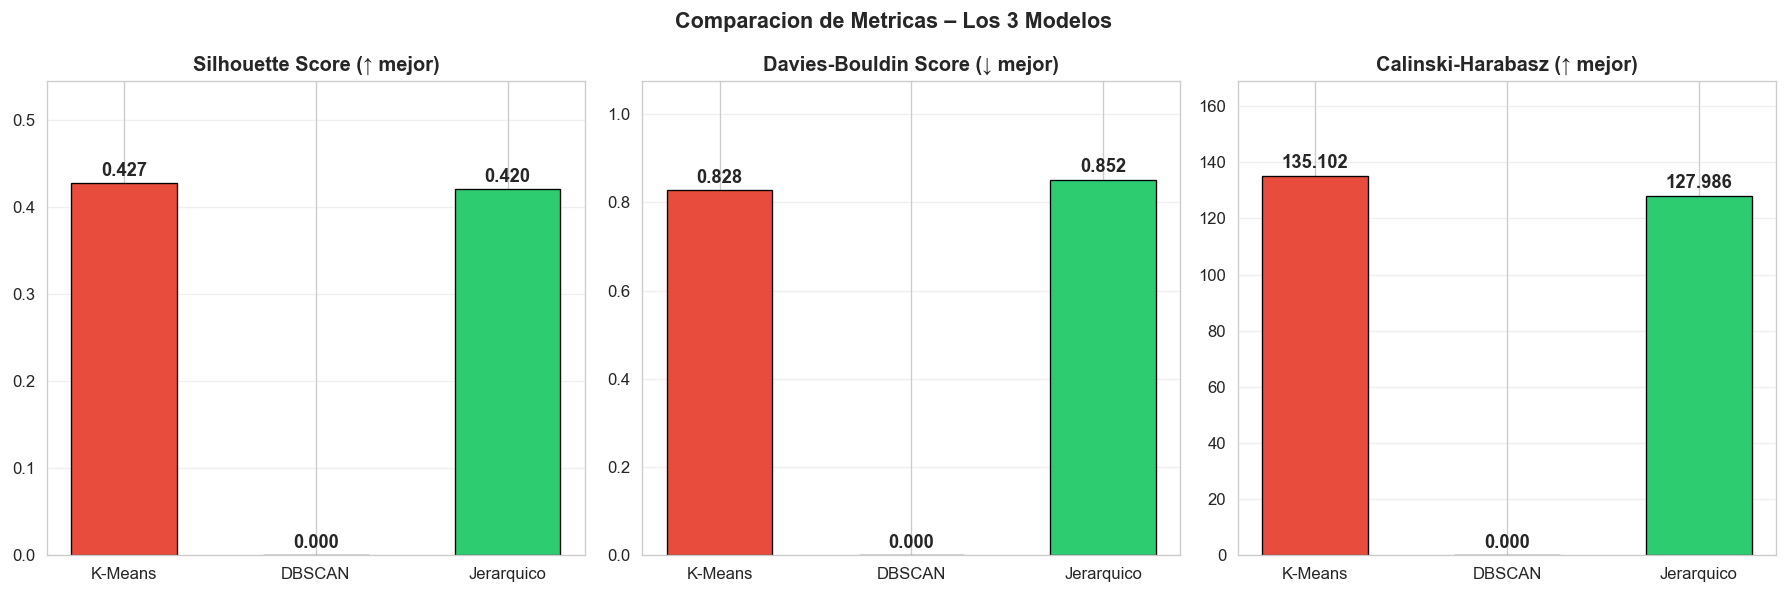

In [26]:
# ── Grafico comparativo ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparacion de Metricas – Los 3 Modelos',
             fontsize=13, fontweight='bold')

nombres = ['K-Means', 'DBSCAN', 'Jerarquico']
colores = ['#e74c3c', '#3498db', '#2ecc71']

metricas_comp = [
    ('Silhouette Score (↑ mejor)',     [sil_km, sil_db, sil_hier]),
    ('Davies-Bouldin Score (↓ mejor)', [db_km,  db_db,  db_hier]),
    ('Calinski-Harabasz (↑ mejor)',    [ch_km,  0,      ch_hier]),
]

for ax, (titulo, vals) in zip(axes, metricas_comp):
    bars = ax.bar(nombres, vals, color=colores, edgecolor='black', lw=0.8, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.25 + 0.01)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Interpretacion de segmentos

In [27]:
# ── Perfil de cada segmento ──────────────────────────────────
perfil_final = df.groupby('Cluster_KMeans').agg(
    Edad_Prom        = ('Age',                    'mean'),
    Ingreso_Prom     = ('Annual Income (k$)',      'mean'),
    Spending_Prom    = ('Spending Score (1-100)',  'mean'),
    Edad_Rango       = ('Age',                    lambda x: f'{x.min()}-{x.max()}'),
    Cantidad         = ('Age',                    'count'),
).round(1)

def etiquetar(row):
    ing = row['Ingreso_Prom']
    sp  = row['Spending_Prom']
    if   ing < 45 and sp < 45:  return 'Bajo Ingreso / Bajo Gasto'
    elif ing < 45 and sp >= 55: return 'Bajo Ingreso / Alto Gasto'
    elif ing >= 65 and sp < 45: return 'Alto Ingreso / Conservador'
    elif ing >= 65 and sp >= 55:return 'Alto Ingreso / Premium'
    else:                       return 'Ingreso y Gasto Moderados'

perfil_final['Segmento'] = perfil_final.apply(etiquetar, axis=1)

print('🎯 PERFIL FINAL DE SEGMENTOS:')
display(perfil_final)

🎯 PERFIL FINAL DE SEGMENTOS:


,Edad_Prom,Ingreso_Prom,Spending_Prom,Edad_Rango,Cantidad,Segmento
Cluster_KMeans,,,,,,
0,41.9,88.9,17.0,19-59,33,Alto Ingreso / Conservador
1,56.3,54.3,49.1,43-70,45,Ingreso y Gasto Moderados
2,25.2,25.8,76.9,18-35,24,Bajo Ingreso / Alto Gasto
3,32.7,86.5,82.1,27-40,39,Alto Ingreso / Premium
4,26.7,57.6,47.8,18-40,38,Ingreso y Gasto Moderados
5,45.5,26.3,19.4,20-67,21,Bajo Ingreso / Bajo Gasto


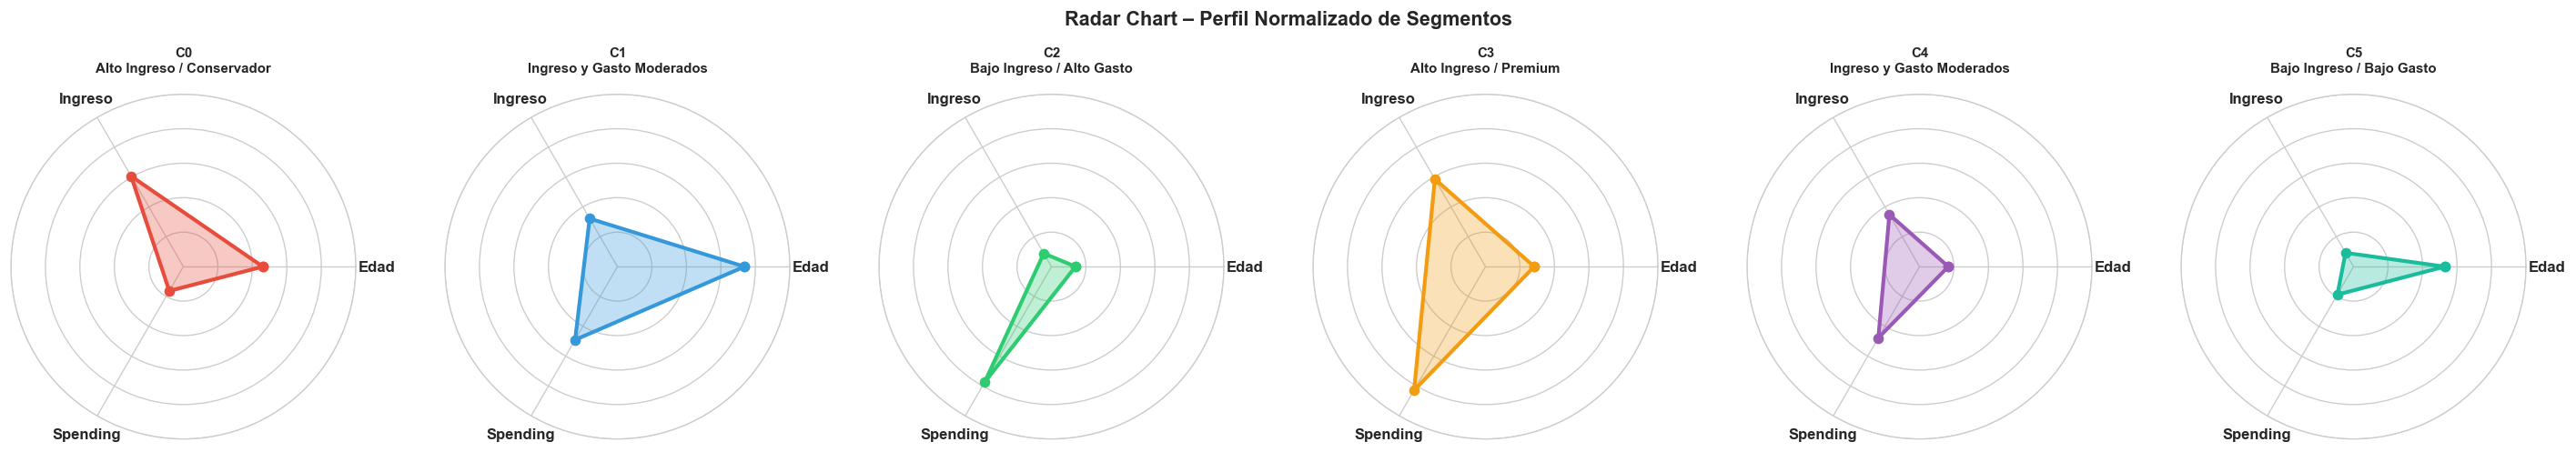

In [28]:
# ── Radar Chart por segmento ─────────────────────────────────
categorias  = ['Edad', 'Ingreso', 'Spending']
N           = len(categorias)
angulos     = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos    += angulos[:1]

centros      = scaler.inverse_transform(kmeans.cluster_centers_)
mins         = X.min(axis=0)
maxs         = X.max(axis=0)
centros_norm = (centros - mins) / (maxs - mins)

fig, axes = plt.subplots(1, K_OPT, figsize=(4*K_OPT, 4),
                         subplot_kw=dict(polar=True))
if K_OPT == 1: axes = [axes]
fig.suptitle('Radar Chart – Perfil Normalizado de Segmentos',
             fontsize=13, fontweight='bold', y=1.02)

for k, ax in enumerate(axes):
    vals  = centros_norm[k].tolist() + centros_norm[k].tolist()[:1]
    ax.plot(angulos, vals, 'o-', color=COLORS[k], lw=2.5)
    ax.fill(angulos, vals, color=COLORS[k], alpha=0.3)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    seg = perfil_final.loc[k,'Segmento'] if k in perfil_final.index else f'C{k}'
    ax.set_title(f'C{k}\n{seg}', fontsize=9, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

## 12. Conclusiones y recomendaciones

In [29]:
best_idx = summary['Silhouette ↑'].astype(float).idxmax()
best_model = summary.loc[best_idx, 'Modelo']
best_sil = summary.loc[best_idx, 'Silhouette ↑']
pca_var = float(sum(var) * 100)
noise_pct = (n_noise / len(df) * 100) if len(df) else 0

summary_md = "\n".join([
    "**Conclusiones basadas en resultados**",
    f"- Mejor modelo segun Silhouette: {best_model} (Silhouette={best_sil:.4f}).",
    f"- Numero de clusters usado en modelos con k: {K_OPT}.",
    f"- DBSCAN detecto {n_noise} puntos de ruido ({noise_pct:.1f}%).",
    f"- PCA (2 componentes) explica {pca_var:.1f}% de la varianza.",
    "- K-Means ofrece grupos compactos; DBSCAN resalta outliers; jerarquico confirma estructura.",
    "- Recomendaciones: ajustar k/eps y evaluar incluir genero si aporta valor.",
    "- Limitaciones: K-Means asume clusters esfericos; DBSCAN es sensible a eps/min_samples.",
])

display(Markdown(summary_md))

**Conclusiones basadas en resultados**
- Mejor modelo segun Silhouette: K-Means (Silhouette=0.4274).
- Numero de clusters usado en modelos con k: 6.
- DBSCAN detecto 14 puntos de ruido (7.0%).
- PCA (2 componentes) explica 77.6% de la varianza.
- K-Means ofrece grupos compactos; DBSCAN resalta outliers; jerarquico confirma estructura.
- Recomendaciones: ajustar k/eps y evaluar incluir genero si aporta valor.
- Limitaciones: K-Means asume clusters esfericos; DBSCAN es sensible a eps/min_samples.